
[INFO] Total records loaded: 3731
[INFO] Experiments processed: 3
[INFO] Horizons: ['horizon_12', 'horizon_24', 'horizon_3', 'horizon_6']


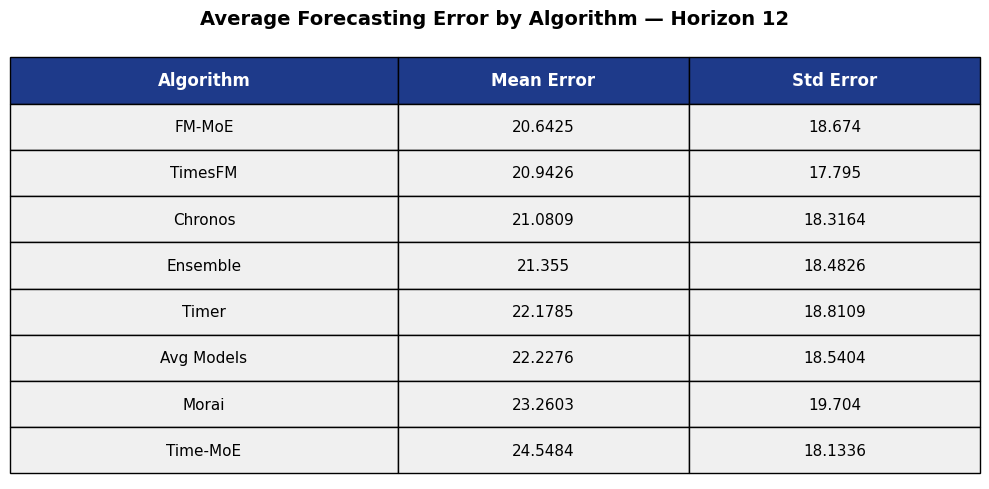

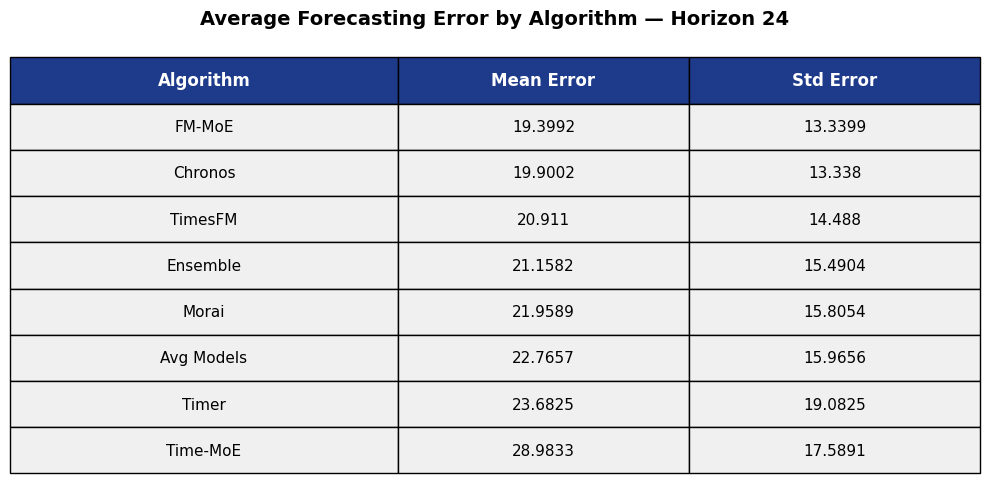

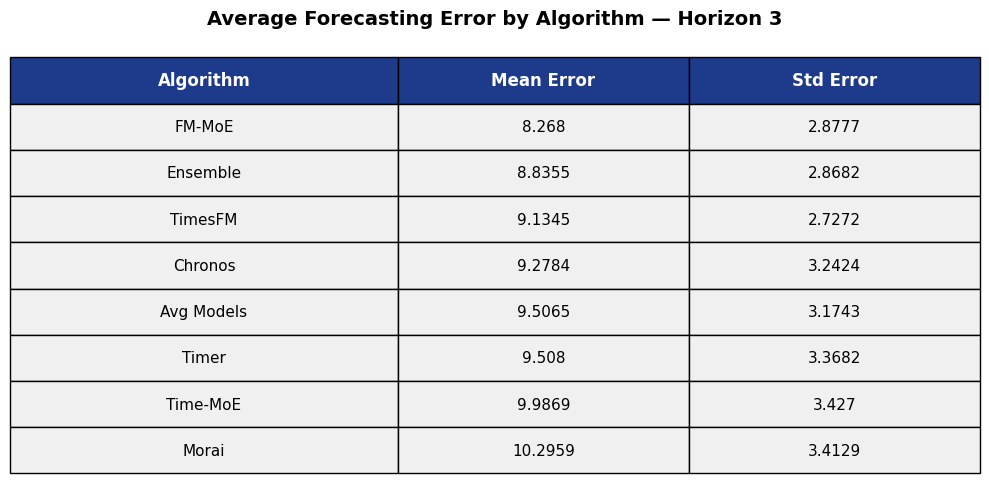

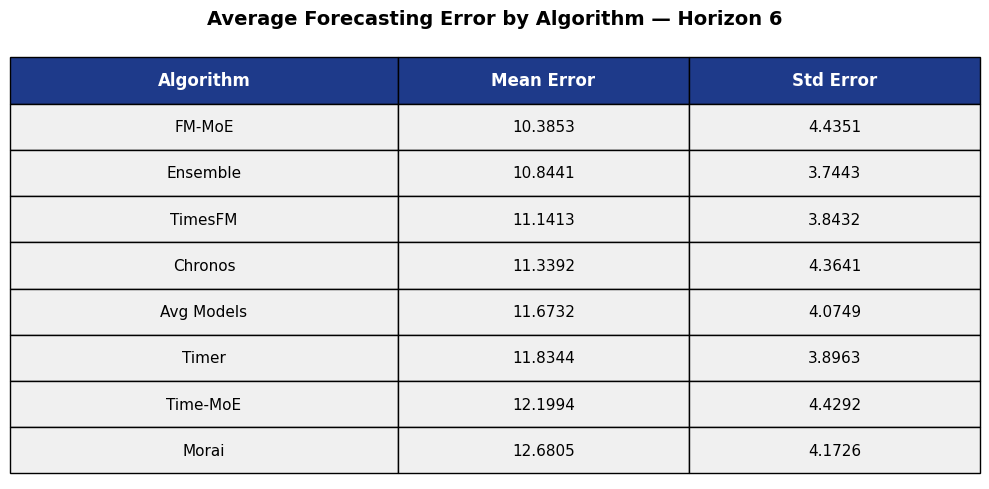


Tables successfully generated.

Summary:
- Total records: 3731
- Unique algorithms: 7
- Horizons: horizon_12, horizon_24, horizon_3, horizon_6


In [1]:
# ==========================================================
# IMPORTS
# ==========================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ==========================================================
# CONFIGURATION
# ==========================================================
BASE_RESULTS_PATH = "Paper/results_by_state_year"

TARGET_PRODUCTS = [
    "Etanolhidratado",
    "Gasolinac",
    "Glp",
    "Oleodiesel",
    "Querosenedeaviacao"
]

BEST_EXPERIMENTS = {

    "horizon_3":  "model_topk_2_norm_std_noise_True_ep_30_lr_0.001",
    "horizon_6":  "model_topk_2_norm_std_noise_True_ep_30_lr_0.001",
    "horizon_12": "model_topk_2_norm_std_noise_True_ep_100_lr_0.0001",
    "horizon_24": "model_topk_2_norm_std_noise_True_ep_60_lr_0.001"
}


# ==========================================================
# LOAD RESULTS
# ==========================================================
rows_all = []

for horizon, exp_name in BEST_EXPERIMENTS.items():

    exp_path = os.path.join(BASE_RESULTS_PATH, exp_name)

    if not os.path.isdir(exp_path):
        print(f"[WARNING] Experiment not found: {exp_path}")
        continue

    for horizon_folder in os.listdir(exp_path):

        horizon_path = os.path.join(exp_path, horizon_folder)

        if not os.path.isdir(horizon_path):
            continue

        if horizon_folder != horizon:
            continue

        for file in os.listdir(horizon_path):

            if not file.endswith(".csv"):
                continue

            year = os.path.splitext(file)[0]
            file_path = os.path.join(horizon_path, file)

            df = pd.read_csv(file_path)

            metric_cols = [c for c in TARGET_PRODUCTS if c in df.columns]

            if len(metric_cols) == 0:
                print(f"[WARNING] No valid columns in {file_path}")
                continue

            df["mean_error"] = df[metric_cols].mean(axis=1)

            for _, row in df.iterrows():

                rows_all.append({
                    "Algorithm": row["Modelo"],
                    "Horizon": horizon,
                    "Year": year,
                    "Error": row["mean_error"],
                    "Experiment": exp_name
                })


# ==========================================================
# BUILD DATAFRAME
# ==========================================================
df_all = pd.DataFrame(rows_all)

if len(df_all) == 0:

    print("\n[ERROR] No data loaded. Check experiment paths.")

else:

    print(f"\n[INFO] Total records loaded: {len(df_all)}")
    print(f"[INFO] Experiments processed: {df_all['Experiment'].nunique()}")
    print(f"[INFO] Horizons: {sorted(df_all['Horizon'].unique())}")


    # ======================================================
    # SUMMARY TABLE
    # ======================================================
    df_summary = (
        df_all
        .groupby(["Algorithm", "Horizon"])
        .agg(
            Mean_Error=("Error", "mean"),
            Std_Error=("Error", "std")
        )
        .reset_index()
    )

    df_summary = df_summary.sort_values(["Horizon", "Mean_Error"])

    df_summary["Mean_Error"] = df_summary["Mean_Error"].round(4)
    df_summary["Std_Error"] = df_summary["Std_Error"].round(4)

    # Rename columns for paper formatting
    df_summary = df_summary.rename(columns={
        "Mean_Error": "Mean Error",
        "Std_Error": "Std Error"
    })


    # ======================================================
    # TABLE VISUALIZATION
    # ======================================================
    horizons = sorted(df_summary["Horizon"].unique())

    for horizon in horizons:

        df_h = df_summary[df_summary["Horizon"] == horizon].copy()

        # Renomeia My-MoE para FM-MoE
        df_h["Algorithm"] = df_h["Algorithm"].replace("My-MoE", "FM-MoE")

        # Linha de média dos modelos exceto FM-MoE
        df_others = df_h[df_h["Algorithm"] != "FM-MoE"]
        others_mean = round(df_others["Mean Error"].mean(), 4)
        others_std  = round(df_others["Std Error"].mean(), 4)

        avg_row = pd.DataFrame([{
            "Algorithm": "Avg Models",
            "Mean Error": others_mean,
            "Std Error":  others_std
        }])

        df_display = pd.concat(
            [df_h[["Algorithm", "Mean Error", "Std Error"]], avg_row],
            ignore_index=True
        )

        # Ordena por Mean Error
        df_display = df_display.sort_values("Mean Error").reset_index(drop=True)

        fig, ax = plt.subplots(figsize=(10, len(df_display) * 0.5 + 1))

        ax.axis("off")
        ax.axis("tight")

        colors = [["#F0F0F0"] * 3 for _ in df_display["Algorithm"]]

        table = ax.table(
            cellText=df_display.values,
            colLabels=df_display.columns,
            cellLoc="center",
            loc="center",
            colWidths=[0.4, 0.3, 0.3],
            cellColours=colors
        )

        table.auto_set_font_size(False)
        table.set_fontsize(11)
        table.scale(1, 2.5)

        # Header style
        for i in range(len(df_display.columns)):
            cell = table[(0, i)]
            cell.set_facecolor("#1E3A8A")
            cell.set_text_props(weight="bold", color="white", fontsize=12)

        horizon_number = horizon.split("_")[-1]

        plt.title(
            f"Average Forecasting Error by Algorithm — Horizon {horizon_number}",
            fontsize=14,
            fontweight="bold",
            pad=20
        )

        plt.tight_layout()
        plt.show()


    print("\nTables successfully generated.")
    print("\nSummary:")
    print(f"- Total records: {len(df_all)}")
    print(f"- Unique algorithms: {df_all['Algorithm'].nunique()}")
    print(f"- Horizons: {', '.join(horizons)}")